# 04 — คอขวดและความซ้ำซ้อน (Performance)

คำถามที่ตอบ
- ขั้นตอนไหนใช้เวลารอนานที่สุด และเกิดกับกลุ่มใดเป็นพิเศษ
- มีการทำซ้ำ (rework) ที่ไหน บ่อยแค่ไหน และแยกจากกรณีที่เคสมีเอกสารหลายใบได้อย่างไร

เวลาวัดจาก timestamp ของ event (ละเอียดระดับนาที) ข้อมูลเป็น **ข้อมูลจำลอง** สาเหตุทุกข้อเป็นข้อสันนิษฐาน

In [1]:
import os; os.environ['PM4PY_SHOW_PROGRESS_BAR'] = 'False'
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt, pm4py
import p2p_data as d
FIG = Path.cwd().parent/'figures'; R = {}
df = d.load_case_log()
con = d.connect(); xo = d.event_object_table(con)
case_of_event = df.set_index('ocel_event_id')['case:concept:name']
xo['case'] = xo.ocel_event_id.map(case_of_event)
N = df['case:concept:name'].nunique()
DAY = 86400
def days(td): return td.dt.total_seconds()/DAY
def stats(s):
    s = s.dropna()
    return {'n': int(s.size), 'median': round(s.median(),2), 'mean': round(s.mean(),2), 'p90': round(s.quantile(.9),2), 'max': round(s.max(),2)}

## 1. ระยะเวลาทั้งเคส

In [2]:
span = df.groupby('case:concept:name')['time:timestamp'].agg(['min','max'])
dur = days(span['max'] - span['min'])
R['case_duration_days'] = stats(dur)
R['case_duration_days']

{'n': 927,
 'median': np.float64(21.75),
 'mean': np.float64(22.53),
 'p90': np.float64(32.78),
 'max': np.float64(66.02)}

## 2. เวลารอระหว่างขั้น (ระดับเอกสาร)
วัดบนเอกสารใบเดียวกันเท่านั้น เพื่อไม่ให้ปนกับเวลาระหว่างเอกสารคนละใบในเคสเดียวกัน

In [3]:
def t_first(obj_type, activity):
    s = xo[(xo.object_type==obj_type)&(xo.activity==activity)]
    return s.groupby('ocel_object_id').ocel_time.min()
def t_last(obj_type, activity):
    s = xo[(xo.object_type==obj_type)&(xo.activity==activity)]
    return s.groupby('ocel_object_id').ocel_time.max()

pr_create = t_first('purchase_requisition','Create Purchase Requisition')
pr_appr   = t_first('purchase_requisition','Approve Purchase Requisition')
pr_deleg  = t_first('purchase_requisition','Delegate Purchase Requisition Approval')
pr_rfq    = t_first('purchase_requisition','Create Request for Quotation')
q_rfq     = t_first('quotation','Create Request for Quotation')
q_po_first= t_first('quotation','Create Purchase Order')
po_create = t_first('purchase_order','Create Purchase Order')
po_appr   = t_first('purchase_order','Approve Purchase Order')
po_gr     = t_first('purchase_order','Create Goods Receipt')
gr_first  = t_first('goods receipt','Create Goods Receipt')
gr_last   = t_last('goods receipt','Create Goods Receipt')
gr_inv    = t_first('goods receipt','Create Invoice Receipt')
gr_match  = t_first('goods receipt','Perform Two-Way Match')
gr_pay    = t_first('goods receipt','Execute Payment')

stages = {
 '1 PR created -> PR approved':            days(pr_appr - pr_create.reindex(pr_appr.index)),
 '1b PR created -> approval delegated':    days(pr_deleg - pr_create.reindex(pr_deleg.index)),
 '2 PR approved -> RFQ':                   days(pr_rfq.reindex(pr_appr.index) - pr_appr),
 '3 RFQ -> first PO created':              days(q_po_first - q_rfq.reindex(q_po_first.index)),
 '4 PO created -> PO approved':            days(po_appr - po_create.reindex(po_appr.index)),
 '5 PO approved -> first goods receipt':   days(po_gr - po_appr.reindex(po_gr.index)),
 '6 first goods receipt -> invoice':       days(gr_inv - gr_first.reindex(gr_inv.index)),
 '7 invoice -> two-way match':             days(gr_match - gr_inv.reindex(gr_match.index)),
 '8 two-way match -> first payment':       days(gr_pay - gr_match.reindex(gr_pay.index)),
}
st = pd.DataFrame({k: stats(v) for k,v in stages.items()}).T
R['stage_wait_days'] = st.to_dict('index')
st

,n,median,mean,p90,max
1 PR created -> PR approved,607.0,2.43,3.37,7.30,28.39
1b PR created -> approval delegated,122.0,0.06,0.32,0.68,2.73
2 PR approved -> RFQ,607.0,2.89,3.84,7.81,26.99
3 RFQ -> first PO created,927.0,0.90,1.30,2.82,8.62
4 PO created -> PO approved,1598.0,2.83,3.64,7.81,25.34
5 PO approved -> first goods receipt,1598.0,3.01,3.92,8.31,25.60
6 first goods receipt -> invoice,1941.0,2.41,2.82,5.58,17.46
7 invoice -> two-way match,1941.0,0.23,0.49,1.85,2.71
8 two-way match -> first payment,1941.0,2.93,3.76,8.01,24.32


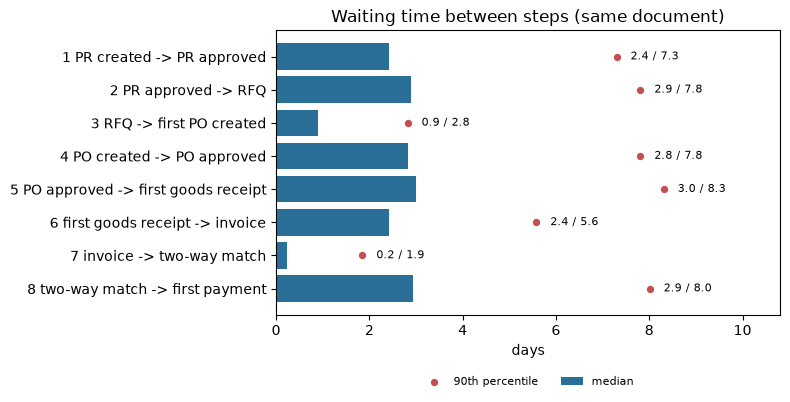

In [4]:
plot = st.drop(index='1b PR created -> approval delegated').iloc[::-1]
fig, ax = plt.subplots(figsize=(8,4.2))
ax.barh(plot.index, plot['median'], color='#2a6f97', label='median')
ax.scatter(plot['p90'], plot.index, color='#c44e52', zorder=3, label='90th percentile', s=18)
for y,(m,p) in enumerate(zip(plot['median'], plot['p90'])): ax.text(max(m,p)+0.3, y, f'{m:.1f} / {p:.1f}', va='center', fontsize=8)
ax.set_xlabel('days'); ax.set_title('Waiting time between steps (same document)'); ax.legend(loc='upper center', bbox_to_anchor=(0.5,-0.18), ncol=2, fontsize=8, frameon=False)
ax.set_xlim(0, plot['p90'].max()*1.3)
fig.tight_layout(); fig.savefig(FIG/'04_stage_waits.png', dpi=150)

In [5]:
share = st['median'].drop(index='1b PR created -> approval delegated')
R['longest_stage_by_median'] = share.idxmax()
R['longest_stage_median_days'] = float(share.max())
R['longest_stage_by_p90'] = st['p90'].drop(index='1b PR created -> approval delegated').idxmax()
R['longest_stage_by_median'], R['longest_stage_median_days'], R['longest_stage_by_p90']

('5 PO approved -> first goods receipt',
 3.01,
 '5 PO approved -> first goods receipt')

ไม่มีขั้นไหนที่โดดเด่นเป็นคอขวดเดียว ขั้นหลักแต่ละขั้นรอประมาณ 2–3 วัน เวลารวมจึงมาจาก **การส่งต่องานหลายทอด**
แยกเวลารอเป็นงานภายใน (อนุมัติ/เอกสาร) กับรอผู้ขายส่งของ เพื่อดูว่าส่วนไหนองค์กรควบคุมได้

In [6]:
kind = {'1 PR created -> PR approved':'internal: approval', '2 PR approved -> RFQ':'internal: handoff',
        '3 RFQ -> first PO created':'internal: handoff', '4 PO created -> PO approved':'internal: approval',
        '5 PO approved -> first goods receipt':'external: supplier delivery', '6 first goods receipt -> invoice':'external: supplier invoicing',
        '7 invoice -> two-way match':'internal: finance', '8 two-way match -> first payment':'internal: finance'}
k = st.loc[list(kind)].assign(kind=pd.Series(kind))
k['group'] = k.kind.str.split(':').str[0]
summ = k.groupby('group')['median'].sum().round(2)
R['sum_of_stage_medians_by_group'] = summ.to_dict()
R['internal_share_of_stage_medians_pct'] = round(100*summ['internal']/summ.sum(),1)
display(k[['kind','median','p90']]); summ

,kind,median,p90
1 PR created -> PR approved,internal: approval,2.43,7.30
2 PR approved -> RFQ,internal: handoff,2.89,7.81
3 RFQ -> first PO created,internal: handoff,0.90,2.82
4 PO created -> PO approved,internal: approval,2.83,7.81
5 PO approved -> first goods receipt,external: supplier delivery,3.01,8.31
6 first goods receipt -> invoice,external: supplier invoicing,2.41,5.58
7 invoice -> two-way match,internal: finance,0.23,1.85
8 two-way match -> first payment,internal: finance,2.93,8.01


group
external     5.42
internal    12.21
Name: median, dtype: float64

ผลรวมค่ามัธยฐานของแต่ละขั้นใช้ดูสัดส่วนคร่าวๆ เท่านั้น (ไม่เท่ากับเวลาทั้งเคส เพราะเคสมีเอกสารหลายใบทำคู่ขนานกัน และเส้นทางที่ไม่มี PR ไม่มีขั้น 1–2)

## 3. Performance DFG (ระดับเคส)
ภาพเวลาเฉลี่ยของคู่ activity ที่ต่อกันในเคส ใช้ดูภาพรวมเท่านั้น เพราะบางคู่เป็นเอกสารคนละใบ

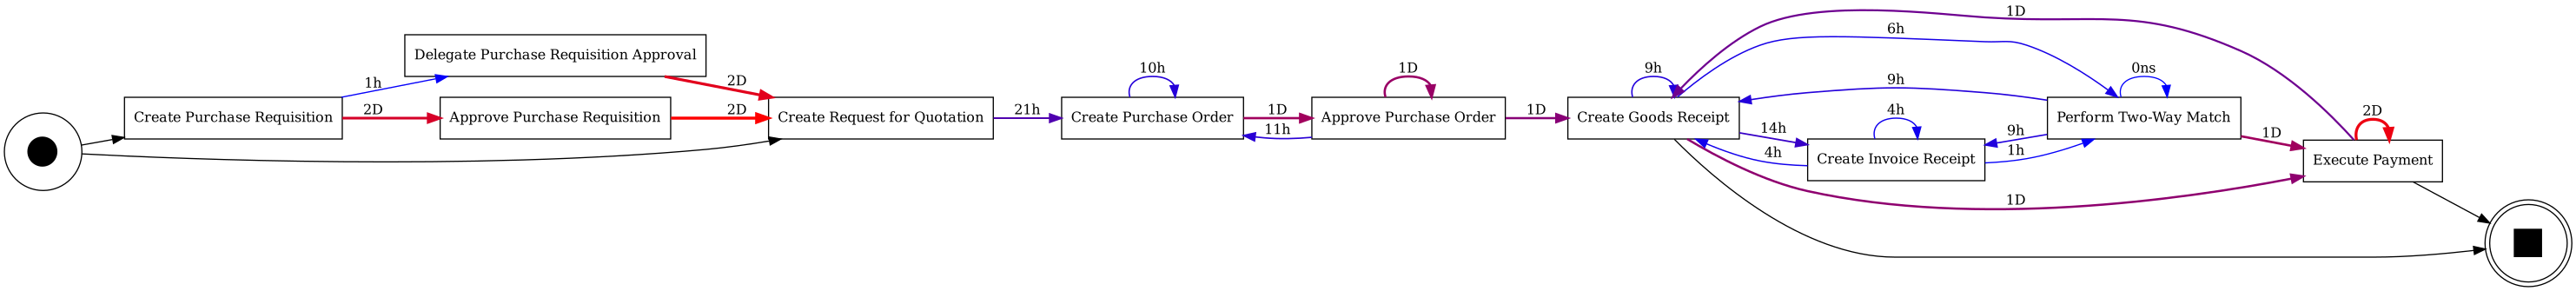

In [7]:
log = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')
pdfg, sa, ea = pm4py.discover_performance_dfg(log)
pm4py.save_vis_performance_dfg(pdfg, sa, ea, str(FIG/'04_performance_dfg.png'), aggregation_measure='median')
from IPython.display import Image; Image(str(FIG/'04_performance_dfg.png'))

## 4. แยกตามกลุ่ม
ใช้ค่ามัธยฐานของระยะเวลาทั้งเคส และของขั้นที่รอนานที่สุด

In [8]:
def init_attrs(t):
    a = d.load_object_attributes(con, t); return a[a.ocel_time.dt.year==1970].set_index('ocel_id')
qa = init_attrs('quotation'); pa = init_attrs('payment')
case = pd.DataFrame(index=dur.index); case['duration'] = dur
pr_of_case = case.index.to_series()
case['path'] = 'PR approved'
case.loc[case.index.isin(pr_deleg.index), 'path'] = 'PR delegated, no approval'
case.loc[~case.index.isin(pr_create.index), 'path'] = 'no PR created'
q_case = xo[xo.object_type=='quotation'].groupby('ocel_object_id').case.first()
case['purchasing_group'] = pd.Series(qa.PurchasingGroupEBANEKGRP.reindex(q_case.index).values, index=q_case.values).reindex(case.index)
case['vendor'] = pd.Series(qa.VendorEBANLIFNR.reindex(q_case.index).values, index=q_case.values).reindex(case.index)
p_case = xo[xo.object_type=='payment'].groupby('ocel_object_id').case.first()
case['payment_method'] = pd.Series(pa.PaymentMethodZLSCH.reindex(p_case.index).values, index=p_case.values).reindex(case.index)
docs = xo[xo.object_type.isin(['purchase_order','goods receipt'])].groupby(['case','object_type']).ocel_object_id.nunique().unstack()
case['POs'] = docs['purchase_order']; case['GRs'] = docs['goods receipt']
case['repeated_payment'] = case.index.isin(xo[(xo.object_type=='payment')&(xo.activity=='Execute Payment')].groupby('case').size().loc[lambda s:s>1].index)
case.isna().sum()

duration            0
path                0
purchasing_group    0
vendor              0
payment_method      0
POs                 0
GRs                 0
repeated_payment    0
dtype: int64

In [9]:
def by(col):
    g = case.groupby(col).duration.agg(cases='size', median='median', mean='mean', p90=lambda s:s.quantile(.9)).round(2)
    return g
groups = {}
for col in ['path','purchasing_group','payment_method','POs','repeated_payment']:
    groups[col] = by(col); display(groups[col])
R['duration_by_group'] = {k: v.reset_index().astype({v.index.name or k: str}).to_dict('records') for k,v in groups.items()}

,cases,median,mean,p90
path,,,,
PR approved,607,23.60,24.53,35.33
"PR delegated, no approval",122,19.77,20.48,29.77
no PR created,198,16.59,17.68,26.94


,cases,median,mean,p90
purchasing_group,,,,
001,159,19.24,19.72,28.82
002,189,23.07,23.78,35.55
003,192,21.96,22.75,33.07
004,194,22.59,23.20,35.45
005,193,21.98,22.74,31.85


,cases,median,mean,p90
payment_method,,,,
A: Bank TransferB: Check,304,21.43,21.90,31.33
C: Bank Collection,319,22.65,23.45,33.23
D:Direct Debit,304,21.54,22.21,33.02


,cases,median,mean,p90
POs,,,,
1,494,20.31,21.15,31.84
2,250,22.41,23.33,32.88
3,128,23.45,24.75,35.90
4,55,24.45,26.16,36.27


,cases,median,mean,p90
repeated_payment,,,,
False,739,21.07,21.44,30.39
True,188,25.92,26.83,37.74


In [10]:
# ผู้ขาย: 50 ราย ดูเฉพาะรายที่มีเคส >= 10
v = case.groupby('vendor').duration.agg(cases='size', median='median').round(2)
v = v[v.cases>=10].sort_values('median')
R['vendor_duration_median_range'] = [float(v['median'].min()), float(v['median'].max())]
R['vendors_with_10plus_cases'] = len(v)
pd.concat([v.head(5), v.tail(5)])

,cases,median
vendor,,
Professional Cycling Products,10,15.96
Bike Components Corp,29,17.20
Precision Gears Ltd,15,18.02
Advanced Bike Frames Inc,19,18.48
Quality Helmets Co,18,18.59
Brake Bosses Ltd,27,24.77
Speedometer Specialists Co,19,25.27
Hub Heroes Ltd,11,25.50
Cable Creators Inc,15,27.86


(np.float64(0.214), np.float64(0.254))

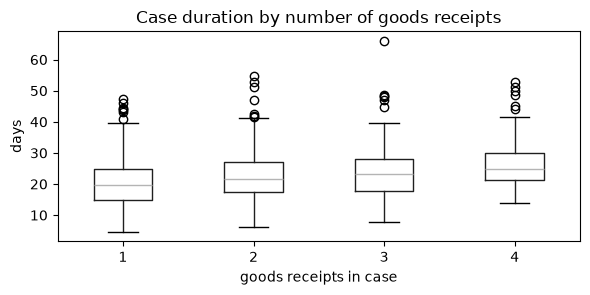

In [11]:
# ความสัมพันธ์ระหว่างจำนวน PO กับระยะเวลา
R['corr_duration_vs_POs'] = round(case.duration.corr(case.POs, method='spearman'),3)
R['corr_duration_vs_GRs'] = round(case.duration.corr(case.GRs, method='spearman'),3)
fig, ax = plt.subplots(figsize=(6,3.2))
case.boxplot(column='duration', by='GRs', ax=ax, grid=False)
ax.set_title('Case duration by number of goods receipts'); fig.suptitle(''); ax.set_xlabel('goods receipts in case'); ax.set_ylabel('days')
fig.tight_layout(); fig.savefig(FIG/'04_duration_by_grs.png', dpi=150)
R['corr_duration_vs_POs'], R['corr_duration_vs_GRs']

In [12]:
# ขั้นที่รอนานที่สุด แยกตามกลุ่มจัดซื้อและวิธีจ่ายเงิน
longest = R['longest_stage_by_median']
s = stages[longest].dropna()
owner = xo.groupby('ocel_object_id').case.first()
sdf = pd.DataFrame({'wait': s, 'case': owner.reindex(s.index).values})
sdf = sdf.join(case[['purchasing_group','payment_method','path']], on='case')
R['longest_stage_by_purchasing_group'] = sdf.groupby('purchasing_group').wait.median().round(2).to_dict()
R['longest_stage_by_payment_method'] = sdf.groupby('payment_method').wait.median().round(2).to_dict()
R['longest_stage_by_path'] = sdf.groupby('path').wait.median().round(2).to_dict()
{k:R[k] for k in ['longest_stage_by_purchasing_group','longest_stage_by_payment_method','longest_stage_by_path']}

{'longest_stage_by_purchasing_group': {'001': 2.8,
  '002': 3.02,
  '003': 2.81,
  '004': 3.17,
  '005': 3.22},
 'longest_stage_by_payment_method': {'A: Bank TransferB: Check': 2.96,
  'C: Bank Collection': 3.25,
  'D:Direct Debit': 2.83},
 'longest_stage_by_path': {'PR approved': 2.96,
  'PR delegated, no approval': 2.76,
  'no PR created': 3.27}}

In [13]:
# ทุกขั้น แยกตามกลุ่มจัดซื้อ (median)
rows = {}
for name, ser in stages.items():
    ser = ser.dropna(); t = pd.DataFrame({'wait': ser, 'case': owner.reindex(ser.index).values}).join(case[['purchasing_group']], on='case')
    rows[name] = t.groupby('purchasing_group').wait.median()
pg = pd.DataFrame(rows).T.round(2); R['stage_by_purchasing_group'] = pg.to_dict('index'); pg

purchasing_group,001,002,003,004,005
1 PR created -> PR approved,NaN,2.14,2.08,2.70,2.64
1b PR created -> approval delegated,0.06,NaN,NaN,NaN,NaN
2 PR approved -> RFQ,NaN,3.02,2.87,2.88,2.67
3 RFQ -> first PO created,0.87,0.88,0.90,0.93,0.90
4 PO created -> PO approved,2.93,2.65,2.93,2.94,2.79
5 PO approved -> first goods receipt,2.80,3.02,2.81,3.17,3.22
6 first goods receipt -> invoice,2.40,2.47,2.46,2.30,2.39
7 invoice -> two-way match,0.25,0.22,0.21,0.25,0.23
8 two-way match -> first payment,2.35,3.08,3.31,2.95,3.09


## 5. การทำซ้ำ: แยก "เอกสารหลายใบ" ออกจาก "ทำซ้ำบนเอกสารเดิม"
ถ้า activity เกิดหลายครั้งในเคสเพราะมีเอกสารหลายใบ นั่นคือปริมาณงาน ไม่ใช่ rework
rework คือ activity เดียวกันเกิดซ้ำบน **เอกสารใบเดิม**

In [14]:
main_obj = {'Create Purchase Order':'purchase_order','Approve Purchase Order':'purchase_order',
            'Create Goods Receipt':'goods receipt','Create Invoice Receipt':'goods receipt',
            'Perform Two-Way Match':'goods receipt','Execute Payment':'payment',
            'Create Purchase Requisition':'purchase_requisition','Approve Purchase Requisition':'purchase_requisition',
            'Delegate Purchase Requisition Approval':'purchase_requisition','Create Request for Quotation':'quotation'}
rows = []
for act, ot in main_obj.items():
    e = xo[(xo.activity==act)&(xo.object_type==ot)]
    per_case = e.groupby('case').agg(events=('ocel_event_id','nunique'), docs=('ocel_object_id','nunique'))
    per_doc = e.groupby('ocel_object_id').size()
    rep = per_case[per_case.events>1]
    rows.append({'activity': act, 'document': ot, 'events': int(e.ocel_event_id.nunique()),
                 'cases_with_repeat': len(rep),
                 'cases_repeat_only_from_multiple_documents': int((rep.events==rep.docs).sum()),
                 'cases_with_repeat_on_same_document': int((rep.events>rep.docs).sum()),
                 'documents_with_repeat': int((per_doc>1).sum()),
                 'extra_events_on_same_document': int((per_doc-1).sum())})
rw = pd.DataFrame(rows)
R['rework'] = rw.to_dict('records'); rw

,activity,document,events,cases_with_repeat,cases_repeat_only_from_multiple_documents,cases_with_repeat_on_same_document,documents_with_repeat,extra_events_on_same_document
0,Create Purchase Order,purchase_order,1598,433,433,0,0,0
1,Approve Purchase Order,purchase_order,1598,433,433,0,0,0
2,Create Goods Receipt,goods receipt,4042,582,149,433,1241,2101
3,Create Invoice Receipt,goods receipt,1941,582,582,0,0,0
4,Perform Two-Way Match,goods receipt,1941,582,582,0,0,0
5,Execute Payment,payment,1166,188,0,188,188,239
6,Create Purchase Requisition,purchase_requisition,729,0,0,0,0,0
7,Approve Purchase Requisition,purchase_requisition,607,0,0,0,0,0
8,Delegate Purchase Requisition Approval,purchase_requisition,122,0,0,0,0,0
9,Create Request for Quotation,quotation,927,0,0,0,0,0


In [15]:
# การรับของซ้ำบนใบรับของเดียวกัน: ห่างกันกี่วัน
g = xo[(xo.object_type=='goods receipt')&(xo.activity=='Create Goods Receipt')].sort_values('ocel_time')
gap = days(g.groupby('ocel_object_id').ocel_time.diff()).dropna()
R['gr_repeat_gap_days'] = stats(gap)
per_gr = g.groupby('ocel_object_id').size()
R['gr_postings_per_gr'] = per_gr.value_counts().sort_index().to_dict()
R['gr_documents_with_repeat_pct'] = round(100*(per_gr>1).mean(),1)
R['gr_span_first_to_last_days'] = stats(days(gr_last - gr_first))
{k:R[k] for k in ['gr_repeat_gap_days','gr_postings_per_gr','gr_documents_with_repeat_pct','gr_span_first_to_last_days']}

{'gr_repeat_gap_days': {'n': 2101,
  'median': np.float64(1.46),
  'mean': np.float64(2.3),
  'p90': np.float64(5.51),
  'max': np.float64(17.38)},
 'gr_postings_per_gr': {1: 700, 2: 601, 3: 420, 4: 220},
 'gr_documents_with_repeat_pct': np.float64(63.9),
 'gr_span_first_to_last_days': {'n': 1941,
  'median': np.float64(1.26),
  'mean': np.float64(2.49),
  'p90': np.float64(6.81),
  'max': np.float64(20.96)}}

In [16]:
# ทุกครั้งที่ใบรับของเดียวกันถูกบันทึก อ้าง PO คนละใบหรือไม่
gp = xo[xo.activity=='Create Goods Receipt'].pivot_table(index='ocel_event_id', columns='object_type', values='ocel_object_id', aggfunc='first')
t = gp.groupby('goods receipt')['purchase_order'].agg(['nunique','size'])
R['gr_postings_each_reference_different_po_pct'] = round(100*(t['nunique']==t['size']).mean(),1)
R['gr_postings_each_reference_different_po_pct']

np.float64(100.0)

**ข้อค้นพบ:** การบันทึกรับของซ้ำบนใบรับของเดียวกัน ทุกครั้งอ้าง PO คนละใบ จึง**ไม่ใช่ rework** แต่เป็นใบรับของ 1 ใบที่รวมของจากหลาย PO ในเคสเดียวกัน (consolidated receipt)
rework ที่เหลือจริงมีอย่างเดียวคือ `Execute Payment` ซ้ำบน payment เดิม (188 รายการ, ดู D1 ใน 03)

In [17]:
# ผลกระทบต่อเวลาของการจ่ายซ้ำ: เคสที่จ่ายซ้ำ จบช้ากว่าแค่ไหน
R['duration_median_repeated_payment'] = round(case[case.repeated_payment].duration.median(),2)
R['duration_median_single_payment'] = round(case[~case.repeated_payment].duration.median(),2)
R['duration_median_repeated_payment'], R['duration_median_single_payment']

(np.float64(25.92), np.float64(21.07))

## 6. ภาระงานตามแผนก

In [18]:
wl = df.groupby(['org:resource','concept:name']).size().unstack(fill_value=0)
R['events_by_resource_activity'] = {r: {a:int(v) for a,v in row.items() if v} for r,row in wl.iterrows()}
wl.T

org:resource,Finance/Account Department,Manufacturing Department,Procurement Department,Procurement Order Manager,Procurement Requisition Manager,Warehouse Department
concept:name,,,,,,
Approve Purchase Order,0,0,0,1598,0,0
Approve Purchase Requisition,0,0,0,0,607,0
Create Goods Receipt,0,0,0,0,0,4042
Create Invoice Receipt,1941,0,0,0,0,0
Create Purchase Order,0,0,1598,0,0,0
Create Purchase Requisition,0,729,0,0,0,0
Create Request for Quotation,0,0,927,0,0,0
Delegate Purchase Requisition Approval,0,122,0,0,0,0
Execute Payment,1166,0,0,0,0,0


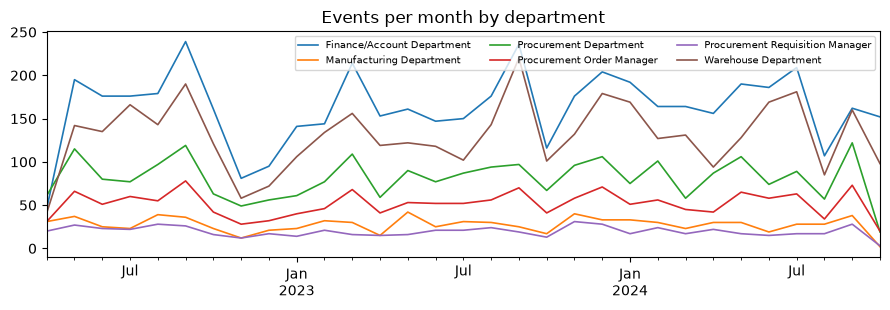

In [19]:
monthly = df.set_index('time:timestamp').groupby('org:resource').resample('MS').size().unstack(0).fillna(0)
R['finance_events_per_month_median'] = float(monthly['Finance/Account Department'].median())
fig, ax = plt.subplots(figsize=(9,3.2)); monthly.plot(ax=ax, lw=1.2)
ax.set_title('Events per month by department'); ax.set_xlabel(''); ax.legend(fontsize=7, ncol=3)
fig.tight_layout(); fig.savefig(FIG/'04_workload_by_department.png', dpi=150)

## 7. บันทึกตัวเลข

In [20]:
case.to_csv(Path.cwd().parent/'data'/'case_attributes.csv')
out = Path.cwd().parent/'results'/'04_performance.json'
out.write_text(json.dumps(R, indent=2, ensure_ascii=False, default=str)); print('saved', len(R), 'keys')

saved 26 keys
